# Zadání 2 - Zjištění stacionárnosti a ergodičnosti náhodného procesu


## Načtení dat a vizualizace realizací náhodného procesu


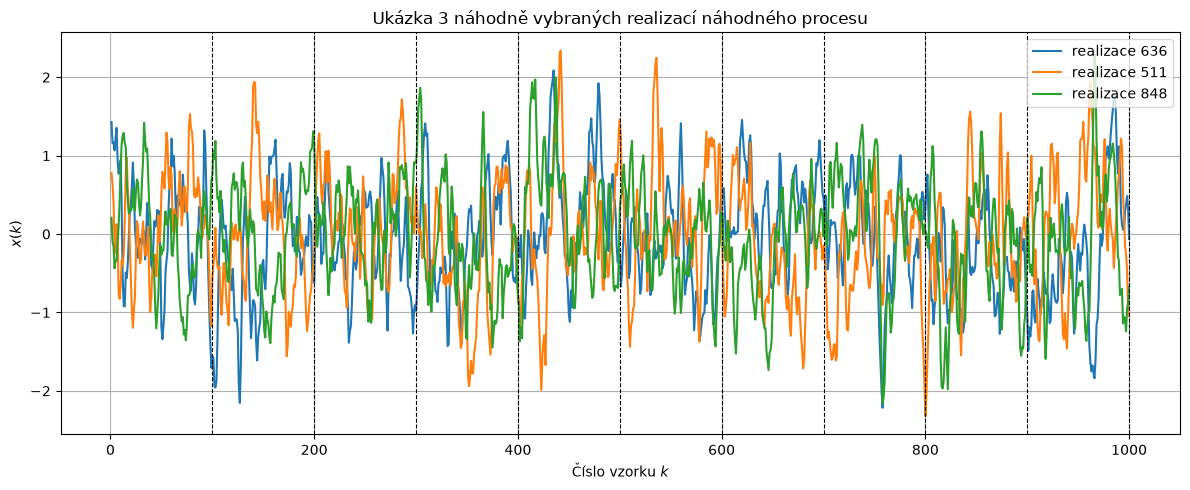

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

with open('a.csv', encoding='utf-8-sig') as f:
    text = f.read()
if ';' in text:
    text = text.replace(',', '.').replace(';', ',')

A = np.array([
    [float(v) for v in re.split(r'[,\s]+', r.strip().strip(',')) if v]
    for r in text.splitlines() if r.strip()
])
if 1 in A.shape:
    A = A.reshape(1000, 1100)
elif A.shape[0] > A.shape[1]:
    A = A.T

n_skip = 100

X = A[:, n_skip:]
M, N = X.shape
k = np.arange(1, N + 1)

idx_pts = np.arange(99, N, 100)
k_pts = k[idx_pts]
K = len(idx_pts)

rng = np.random.default_rng(0)
ukazka = rng.choice(M, 3, replace=False)

plt.figure(figsize=(12, 5))
for j in ukazka:
    plt.plot(k, X[j], label=f'realizace {j}')
for kp in k_pts:
    plt.axvline(kp, color='k', linestyle='--', linewidth=0.8)
plt.title(r'Ukázka 3 náhodně vybraných realizací náhodného procesu')
plt.xlabel(r'Číslo vzorku $k$')
plt.ylabel(r'$x(k)$')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.savefig("realizace.png", dpi=300)
plt.show()


## Vyšetření stacionarity na základě 5, 30 a 1000 realizací


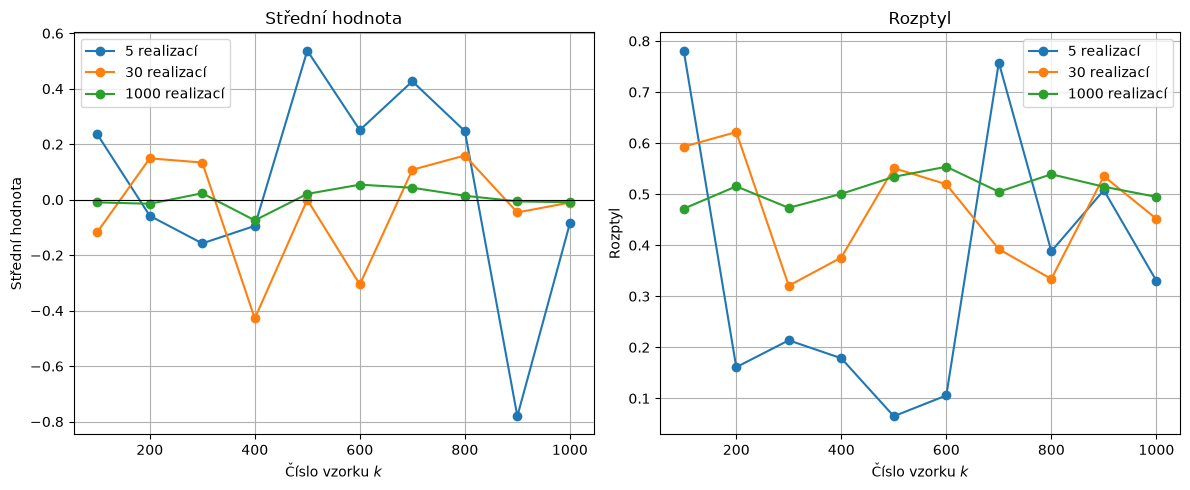

Statistiky časových průběhů středních hodnot a rozptylů:


,Počet realizací,Průměr středních hodnot,Sm. odchylka středních hodnot,Průměr rozptylů,Sm. odchylka rozptylů
0,5,0.05230,0.35739,0.34892,0.24565
1,30,-0.03567,0.18901,0.46944,0.10364
2,1000,0.00422,0.03432,0.51012,0.02559


In [2]:
vyber = {
    5: rng.choice(M, 5, replace=False),
    30: rng.choice(M, 30, replace=False),
    1000: np.arange(M)
}
barvy = {5: 'tab:blue', 30: 'tab:orange', 1000: 'tab:green'}

plt.figure(figsize=(12, 5))
radky = []

for pocet, ind in vyber.items():
    Xs = X[ind][:, idx_pts]
    m_t = np.sum(Xs, axis=0) / len(ind)
    s2_t = np.sum((Xs - m_t) ** 2, axis=0) / len(ind)

    plt.subplot(1, 2, 1)
    plt.plot(k_pts, m_t, 'o-', color=barvy[pocet], label=rf'{pocet} realizací')

    plt.subplot(1, 2, 2)
    plt.plot(k_pts, s2_t, 'o-', color=barvy[pocet], label=rf'{pocet} realizací')

    radky.append([
        pocet,
        f"{np.mean(m_t):.5f}",
        f"{np.std(m_t):.5f}",
        f"{np.mean(s2_t):.5f}",
        f"{np.std(s2_t):.5f}"
    ])

plt.subplot(1, 2, 1)
plt.axhline(0, color='k', linewidth=0.8)
plt.title('Střední hodnota')
plt.xlabel(r'Číslo vzorku $k$')
plt.ylabel('Střední hodnota')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.title('Rozptyl')
plt.xlabel(r'Číslo vzorku $k$')
plt.ylabel('Rozptyl')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("stacionarita.png", dpi=300)
plt.show()

stac_df = pd.DataFrame(radky, columns=[
    'Počet realizací',
    'Průměr středních hodnot',
    'Sm. odchylka středních hodnot',
    'Průměr rozptylů',
    'Sm. odchylka rozptylů'
])
print("Statistiky časových průběhů středních hodnot a rozptylů:")
display(stac_df)


## Střední hodnota a rozptyl z jedné realizace a ze souboru realizací


Porovnání jedné realizace se souborem realizací:


,Veličina,Střední hodnota,Rozptyl
0,Jedna realizace (č. 485): časový průměr,0.04198,0.45234
1,Soubor realizací: průměr přes 10 řezů,0.00422,0.51012
2,Všechny realizace: průměr časových průměrů,0.00282,0.52142
3,Všechny realizace: sm. odchylka časových průměrů,0.07485,0.05773


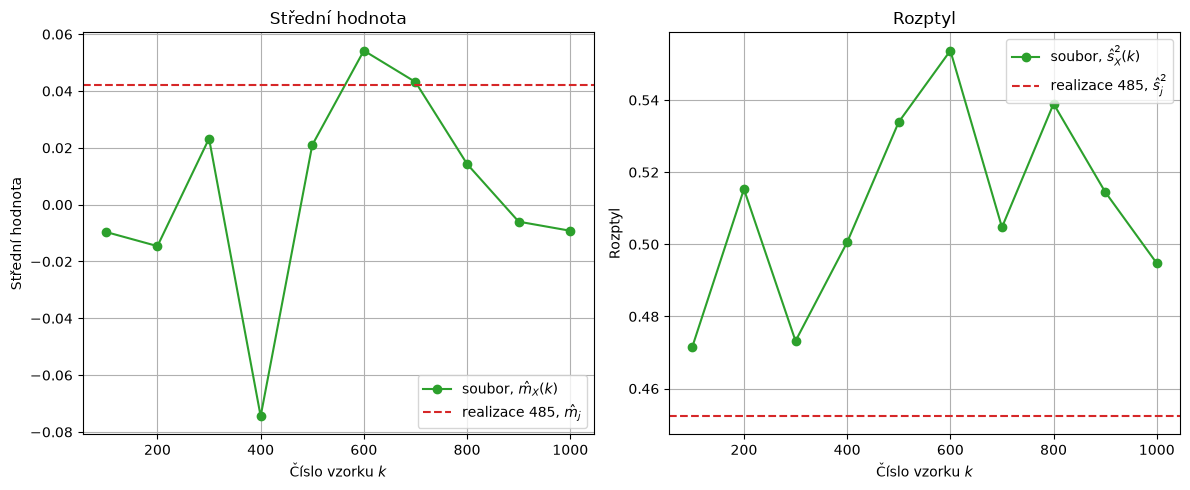

In [3]:
j = int(rng.integers(M))
x1 = X[j]

m_1 = np.sum(x1) / N
s2_1 = np.sum((x1 - m_1) ** 2) / N

Xp = X[:, idx_pts]
m_ens = np.sum(Xp, axis=0) / M
s2_ens = np.sum((Xp - m_ens) ** 2, axis=0) / M

m_casove = np.sum(X, axis=1) / N
s2_casove = np.sum((X - m_casove[:, None]) ** 2, axis=1) / N

souhrn_df = pd.DataFrame({
    'Veličina': [
        f'Jedna realizace (č. {j}): časový průměr',
        'Soubor realizací: průměr přes 10 řezů',
        'Všechny realizace: průměr časových průměrů',
        'Všechny realizace: sm. odchylka časových průměrů'
    ],
    'Střední hodnota': [
        f"{m_1:.5f}",
        f"{np.mean(m_ens):.5f}",
        f"{np.mean(m_casove):.5f}",
        f"{np.std(m_casove):.5f}"
    ],
    'Rozptyl': [
        f"{s2_1:.5f}",
        f"{np.mean(s2_ens):.5f}",
        f"{np.mean(s2_casove):.5f}",
        f"{np.std(s2_casove):.5f}"
    ]
})
print("Porovnání jedné realizace se souborem realizací:")
display(souhrn_df)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_pts, m_ens, 'o-', color='tab:green', label=r'soubor, $\hat{m}_X(k)$')
plt.axhline(m_1, color='tab:red', linestyle='--', label=rf'realizace {j}, $\hat{{m}}_j$')
plt.title('Střední hodnota')
plt.xlabel(r'Číslo vzorku $k$')
plt.ylabel('Střední hodnota')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_pts, s2_ens, 'o-', color='tab:green', label=r'soubor, $\hat{s}_X^2(k)$')
plt.axhline(s2_1, color='tab:red', linestyle='--', label=rf'realizace {j}, $\hat{{s}}_j^2$')
plt.title('Rozptyl')
plt.xlabel(r'Číslo vzorku $k$')
plt.ylabel('Rozptyl')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("jedna_realizace_vs_soubor.png", dpi=300)
plt.show()


## Kovarianční matice náhodných veličin


Kovarianční matice C_X (dle vzorce):


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
X1,0.47159,0.00276,0.00396,-0.01389,-0.00077,0.00296,-0.02183,0.02033,0.00875,-0.00756
X2,0.00276,0.51530,0.00816,-0.01744,0.01508,0.01387,0.01497,0.00032,0.00837,-0.01187
X3,0.00396,0.00816,0.47320,-0.02957,0.02112,-0.01789,0.01898,-0.00580,-0.01017,0.00383
X4,-0.01389,-0.01744,-0.02957,0.50058,0.02088,0.01378,-0.00014,0.01079,0.01845,0.01128
X5,-0.00077,0.01508,0.02112,0.02088,0.53392,0.00650,-0.03553,0.00457,-0.02295,0.01365
X6,0.00296,0.01387,-0.01789,0.01378,0.00650,0.55371,-0.01918,-0.00423,-0.03661,-0.00554
X7,-0.02183,0.01497,0.01898,-0.00014,-0.03553,-0.01918,0.50471,0.00866,0.02249,-0.02692
X8,0.02033,0.00032,-0.00580,0.01079,0.00457,-0.00423,0.00866,0.53897,-0.03263,0.00911
X9,0.00875,0.00837,-0.01017,0.01845,-0.02295,-0.03661,0.02249,-0.03263,0.51452,-0.01017
X10,-0.00756,-0.01187,0.00383,0.01128,0.01365,-0.00554,-0.02692,0.00911,-0.01017,0.49475


Maximální absolutní rozdíl matic (vzorec a funkce cov):
5.55e-17


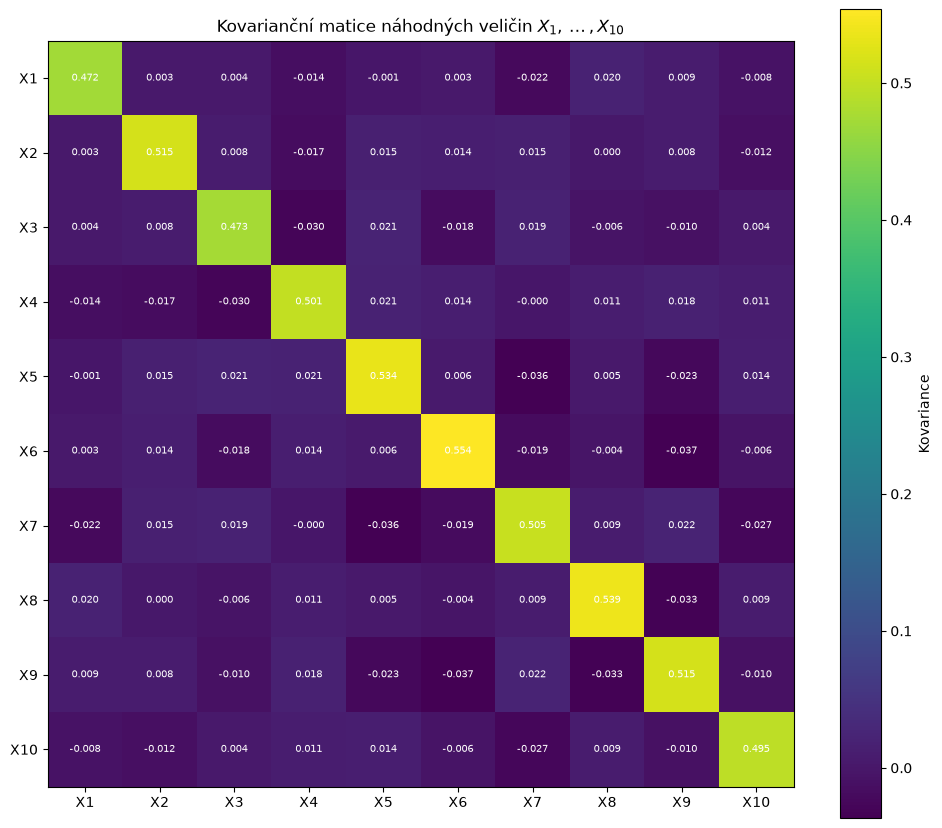

In [4]:
Xc = Xp - m_ens
C_X = (Xc.T @ Xc) / M
C_cov = np.cov(Xp, rowvar=False, bias=True)

popisky = [f'X{k + 1}' for k in range(K)]

print("Kovarianční matice C_X (dle vzorce):")
display(pd.DataFrame(C_X, index=popisky, columns=popisky).round(5))
print("Maximální absolutní rozdíl matic (vzorec a funkce cov):")
print(f"{np.max(np.abs(C_X - C_cov)):.2e}")

plt.figure(figsize=(10, 8.5))
plt.imshow(C_X, cmap='viridis')
plt.colorbar(label='Kovariance')
for p in range(K):
    for q in range(K):
        plt.text(q, p, f"{C_X[p, q]:.3f}", ha='center', va='center', fontsize=7, color='white')
plt.xticks(range(K), popisky)
plt.yticks(range(K), popisky)
plt.title(r'Kovarianční matice náhodných veličin $X_1, \dots, X_{10}$')
plt.tight_layout()
plt.savefig("kovariancni_matice.png", dpi=300)
plt.show()


## Autokovarianční funkce na základě jedné realizace


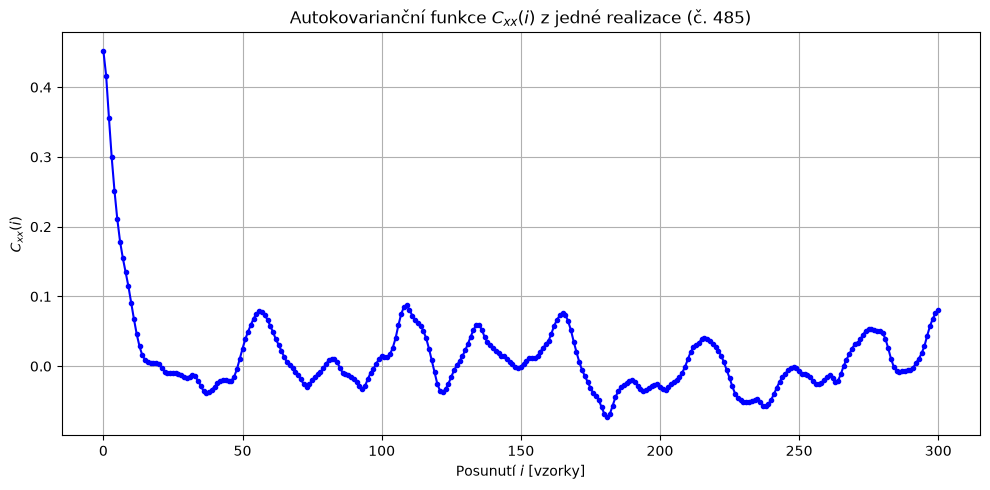

In [5]:
m_max = 300
i_vals = np.arange(0, m_max + 1)

C_jedna = np.zeros(m_max + 1)
for i in range(m_max + 1):
    norm = N - i
    C_jedna[i] = np.sum((x1[:norm] - m_1) * (x1[i:norm + i] - m_1)) / norm

plt.figure(figsize=(10, 5))
plt.plot(i_vals, C_jedna, 'b.-')
plt.title(rf'Autokovarianční funkce $C_{{xx}}(i)$ z jedné realizace (č. {j})')
plt.xlabel(r'Posunutí $i$ [vzorky]')
plt.ylabel(r'$C_{xx}(i)$')
plt.grid(True)
plt.tight_layout()
plt.savefig("autokovariance_jedna.png", dpi=300)
plt.show()


## Autokovarianční funkce na základě souboru realizací


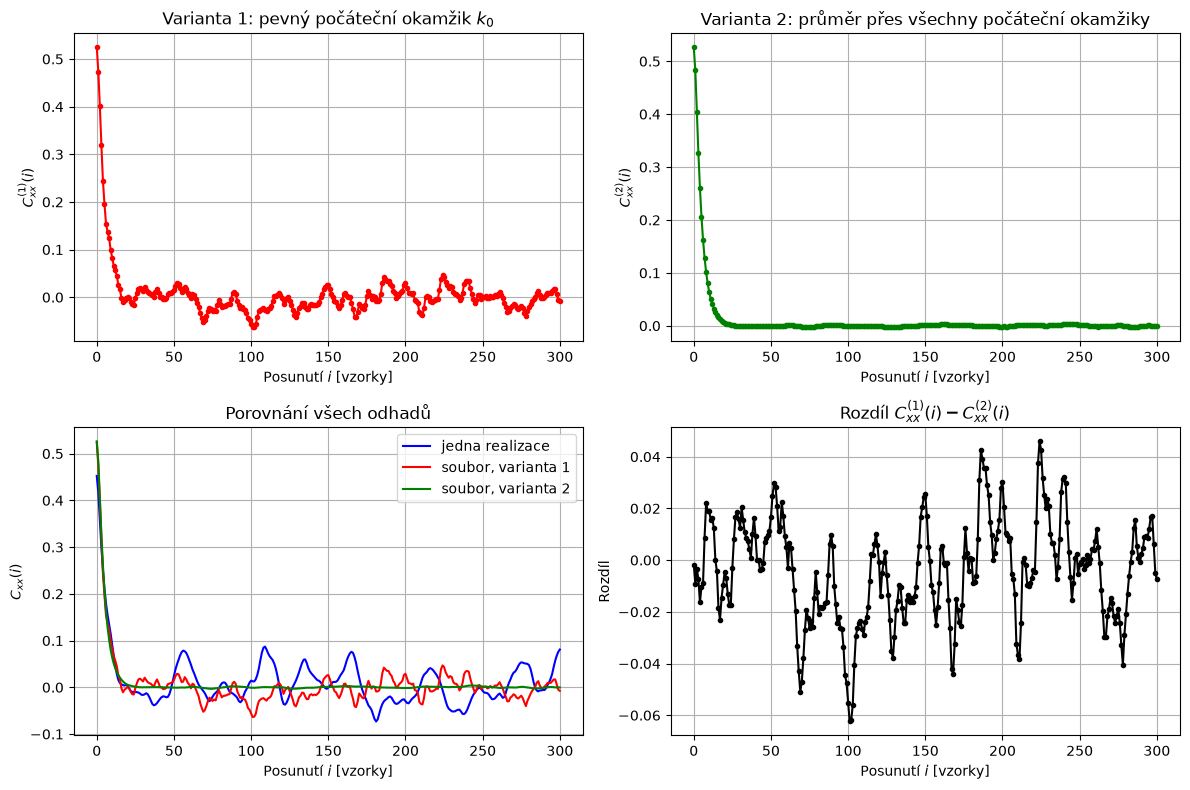

Porovnání odhadů autokovarianční funkce:


,Odhad,C_xx(0),Max. odchylka od varianty 2
0,Jedna realizace,0.45234,0.08669
1,"Soubor, varianta 1",0.52456,0.06240
2,"Soubor, varianta 2",0.52629,-


In [6]:
k0 = 0
Xc_all = X - np.sum(X, axis=0) / M

C_var1 = np.zeros(m_max + 1)
C_var2 = np.zeros(m_max + 1)
for i in range(m_max + 1):
    soucin = Xc_all[:, :N - i] * Xc_all[:, i:]
    C_var1[i] = np.sum(soucin[:, k0]) / M
    C_var2[i] = np.sum(soucin) / (M * (N - i))

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(i_vals, C_var1, 'r.-')
plt.title(r'Varianta 1: pevný počáteční okamžik $k_0$')
plt.xlabel(r'Posunutí $i$ [vzorky]')
plt.ylabel(r'$C^{(1)}_{xx}(i)$')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(i_vals, C_var2, 'g.-')
plt.title(r'Varianta 2: průměr přes všechny počáteční okamžiky')
plt.xlabel(r'Posunutí $i$ [vzorky]')
plt.ylabel(r'$C^{(2)}_{xx}(i)$')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(i_vals, C_jedna, 'b-', label='jedna realizace')
plt.plot(i_vals, C_var1, 'r-', label='soubor, varianta 1')
plt.plot(i_vals, C_var2, 'g-', label='soubor, varianta 2')
plt.title('Porovnání všech odhadů')
plt.xlabel(r'Posunutí $i$ [vzorky]')
plt.ylabel(r'$C_{xx}(i)$')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(i_vals, C_var1 - C_var2, 'k.-')
plt.title(r'Rozdíl $C^{(1)}_{xx}(i) - C^{(2)}_{xx}(i)$')
plt.xlabel(r'Posunutí $i$ [vzorky]')
plt.ylabel('Rozdíl')
plt.grid(True)

plt.tight_layout()
plt.savefig("autokovariance_soubor.png", dpi=300)
plt.show()

akf_df = pd.DataFrame({
    'Odhad': ['Jedna realizace', 'Soubor, varianta 1', 'Soubor, varianta 2'],
    'C_xx(0)': [f"{C_jedna[0]:.5f}", f"{C_var1[0]:.5f}", f"{C_var2[0]:.5f}"],
    'Max. odchylka od varianty 2': [
        f"{np.max(np.abs(C_jedna - C_var2)):.5f}",
        f"{np.max(np.abs(C_var1 - C_var2)):.5f}",
        '-'
    ]
})
print("Porovnání odhadů autokovarianční funkce:")
display(akf_df)


## Závěr

V této úloze jsem se zabýval zjišťováním stacionarity a ergodicity náhodného procesu, který vznikl buzením dynamické soustavy náhodným signálem.

### Postup řešení a vlastní data:
1. **Měření dat:** Spustil jsem skript generování, ve kterém byl nastaven počet realizací na 1000 o délce 1100 vzorků a parametr *Seed* se měnil od 0 po 999.
2. **Zpracování dat:** Hodnoty jsem překopíroval do Excelu a uložil do souboru `a.csv`, se kterým jsem pracoval v Jupyter Notebooku. Prvních 100 vzorků každé realizace jsem vynechal a řezy jsem volil po 100 hodnotách, čímž vzniklo 10 náhodných veličin.
3. **Statistická analýza:** Vyšetřil jsem časové průběhy středních hodnot a rozptylů pro 5, 30 a 1000 realizací, porovnal jednu realizaci se souborem, sestavil kovarianční matici a spočítal autokovarianční funkce z jedné realizace i ze souboru realizací.

### Shrnutí výsledků:
- **Stacionarita a vliv počtu realizací:** Na všech 1000 realizacích se střední hodnota i rozptyl v čase prakticky nemění (průměr středních hodnot $0{,}00422$, průměr rozptylů $0{,}51012$ se směrodatnou odchylkou v čase $0{,}02559$, tj. přibližně 5 % průměru), proces je tedy stacionární. Se zvyšujícím se počtem realizací kolísání výrazně klesá: směrodatná odchylka průběhu střední hodnoty klesla z $0{,}35739$ (5 realizací) přes $0{,}18901$ (30 realizací) na $0{,}03432$ (1000 realizací), u rozptylu z $0{,}24565$ přes $0{,}10364$ na $0{,}02559$. U 5 realizací je navíc průměr rozptylů výrazně nižší ($0{,}34892$ oproti $0{,}51012$), takže by malý soubor mohl vést k chybnému závěru o nestacionaritě.
- **Ergodicita:** Jedna náhodně vybraná realizace (č. 485) dává $m = 0{,}04198$ a $s^2 = 0{,}45234$, soubor realizací $0{,}00422$ a $0{,}51012$. Odchylky ($0{,}03776$ a $0{,}05778$) jsou srovnatelné se směrodatnými odchylkami časových průměrů mezi jednotlivými realizacemi ($0{,}07485$ a $0{,}05773$), jde tedy o běžné výběrové kolísání. Průměry časových průměrů přes všech 1000 realizací ($0{,}00282$ a $0{,}52142$) odpovídají hodnotám ze souboru, proto je proces ergodický ve střední hodnotě i rozptylu.
- **Kovarianční matice:** Matice vypočtená dle vzorce se shoduje s funkcí `np.cov` (rozdíl $5{,}55 \cdot 10^{-17}$). Diagonální prvky (rozptyly v řezech) leží v rozmezí $0{,}472$ až $0{,}554$ a mimodiagonální prvky nepřesahují v absolutní hodnotě $0{,}037$, protože autokovarianční funkce klesá k nule během přibližně 20 posunutí, tedy mnohem dříve než je vzdálenost řezů (100 vzorků).
- **Autokovarianční funkce:** Autokovarianční funkce má maximum v počátku, rovné rozptylu ($C_{xx}(0) = 0{,}45234$ z jedné realizace, $0{,}52456$ varianta 1, $0{,}52629$ varianta 2), a klesá k nule přibližně během 20 posunutí. Odhad z jedné realizace se pro velká posunutí odchyluje od varianty 2 až o $0{,}08669$, protože se průměruje z menšího počtu součinů $N - i$.
- **Varianty autokovariance ze souboru:** Varianta 1 (pevný počáteční okamžik) využívá pouze 1000 součinů pro každé posunutí, proto kolísá kolem nuly (až $0{,}06240$ od varianty 2). Varianta 2 průměruje přes všechny počáteční okamžiky a je výrazně hladší, proto je pro stacionární proces vhodnější.
